 **1 Importation des librairies**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt


**2 Chargement du dataset**


In [ ]:
df = pd.read_excel("BDD_Turnover_Auditeurs.xlsx", header=3)
print(df.head())
print(df.info())
print(df.describe())

  ID Employe  Age  Genre      Ville Niveau Etudes Certification  \
0   AUD-0001   50  Homme  Marrakech        Master           CIA   
1   AUD-0002   36  Homme  Marrakech           MBA           CIA   
2   AUD-0003   29  Homme      Rabat        Master          CISA   
3   AUD-0004   42  Femme     Agadir           MBA        Aucune   
4   AUD-0005   40  Homme     Tanger        Master        Aucune   

             Poste         Type Cabinet  Anciennete Annees  Nb Missions Annee  \
0  Auditeur Junior  Cabinet Indépendant                  8                  5   
1  Auditeur Senior                 Big4                  7                 12   
2  Auditeur Senior                 Big4                 19                  8   
3  Auditeur Junior     Cabinet National                 12                  7   
4  Auditeur Junior                 Big4                 16                  4   

   ...  Promotions 3 Ans  Mentoring  Opportunites Evolution  \
0  ...                 1        Non            

verifications des valeur manquantes

In [ ]:
print(df.isnull().sum())

ID Employe                        0
Age                               0
Genre                             0
Ville                             0
Niveau Etudes                     0
Certification                     0
Poste                             0
Type Cabinet                      0
Anciennete Annees                 0
Nb Missions Annee                 0
Heures Supp Semaine               0
Nb Deplacements Annee             0
Ratio Teletravail                 0
Satisfaction Globale              0
Satisfaction Manager              0
Satisfaction Equipe               0
Satisfaction Remuneration         0
Charge Travail Percue             0
Equilibre Vie Pro                 0
Stress Percu                      0
Salaire Mensuel MAD               0
Augmentation Derniere Pct         0
Bonus Annuel MAD                  0
Formations Annee                  0
Promotions 3 Ans                  0
Mentoring                         0
Opportunites Evolution            0
Plan Carriere Defini        

**Encoder les variables catégorielles**



In [ ]:
# Define X (features) and y (target variable)
X = df.drop('Depart 12mois', axis=1)
y = df['Depart 12mois']

#Variable cible = Depart 12mois
le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = le.fit_transform(X[col])

#encodage de cible
y = le.fit_transform(y)   # Oui = 1 / Non = 0

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)   # Oui=1 / Non=0

**6 Train/Test split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

** 7 Modèle 1 : Régression Logistique**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy Logistic Regression:", accuracy_score(y_test, y_pred_log))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("Classification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy Logistic Regression: 0.71
Confusion Matrix:
[[51 12]
 [17 20]]
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78        63
           1       0.62      0.54      0.58        37

    accuracy                           0.71       100
   macro avg       0.69      0.68      0.68       100
weighted avg       0.70      0.71      0.71       100



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


** 8 Modèle 2 : Arbre de Décision**

In [ ]:
model = DecisionTreeClassifier(max_depth=5, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy :", accuracy)
## Report
print(classification_report(y_test, y_pred))



Accuracy : 0.62
              precision    recall  f1-score   support

           0       0.67      0.78      0.72        63
           1       0.48      0.35      0.41        37

    accuracy                           0.62       100
   macro avg       0.58      0.56      0.56       100
weighted avg       0.60      0.62      0.60       100



** 9 Matrice de confusion**

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[49 14]
 [24 13]]


**10 Importance des variables **

Satisfaction Globale         0.172937
Satisfaction Remuneration    0.108002
Charge Travail Percue        0.098666
Nb Entretiens Exterieurs     0.087516
ID Employe                   0.086242
Nb Changements Emploi        0.063476
Salaire Mensuel MAD          0.062570
Satisfaction Equipe          0.052771
Equilibre Vie Pro            0.049795
Bonus Annuel MAD             0.040251
dtype: float64


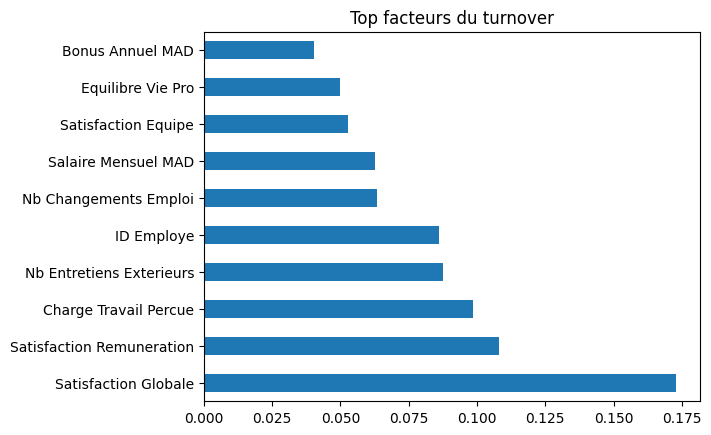

In [ ]:
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

#Graphique
importance.head(10).plot(kind="barh")
plt.title("Top facteurs du turnover")
plt.show()

Comparer les modèles

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression      0.71
1        Decision Tree      0.62


Graphique de comparaison

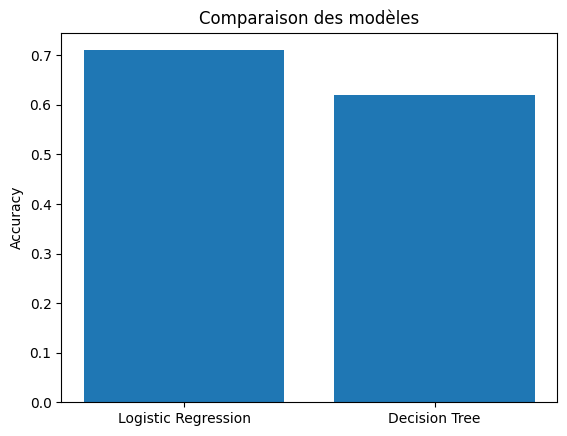

In [ ]:
import matplotlib.pyplot as plt

plt.bar(results["Model"], results["Accuracy"])
plt.title("Comparaison des modèles")
plt.ylabel("Accuracy")
plt.show()